# EXPLORATIVE DATA ANALYSIS(EDA)

In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
df = pd.read_csv('all_data.csv')  #importing the data in to our workstation

df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,4/19/2019 8:46,"917 1st St, Dallas, TX 75001"
1,NaN,NaN,NaN,NaN,NaN,NaN
2,176559,Bose SoundSport Headphones,1,99.99,4/7/2019 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,4/12/2019 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,4/12/2019 14:38,"669 Spruce St, Los Angeles, CA 90001"


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186850 entries, 0 to 186849
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Order ID          186305 non-null  object
 1   Product           186305 non-null  object
 2   Quantity Ordered  186305 non-null  object
 3   Price Each        186305 non-null  object
 4   Order Date        186305 non-null  object
 5   Purchase Address  186305 non-null  object
dtypes: object(6)
memory usage: 8.6+ MB


In [3]:
df.duplicated().sum()
print("The total sum of duplicate is ",df.duplicated().sum())

The total sum of duplicate is  1162


In [4]:
df.drop_duplicates(inplace = True)
# Deleting the duplicate and making it permanet in the dataset

In [5]:
df

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,4/19/2019 8:46,"917 1st St, Dallas, TX 75001"
1,NaN,NaN,NaN,NaN,NaN,NaN
2,176559,Bose SoundSport Headphones,1,99.99,4/7/2019 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,4/12/2019 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,4/12/2019 14:38,"669 Spruce St, Los Angeles, CA 90001"
...,...,...,...,...,...,...
186845,259353,AAA Batteries (4-pack),3,2.99,9/17/2019 20:56,"840 Highland St, Los Angeles, CA 90001"
186846,259354,iPhone,1,700,9/1/2019 16:00,"216 Dogwood St, San Francisco, CA 94016"
186847,259355,iPhone,1,700,9/23/2019 7:39,"220 12th St, San Francisco, CA 94016"
186848,259356,34in Ultrawide Monitor,1,379.99,9/19/2019 17:30,"511 Forest St, San Francisco, CA 94016"


In [6]:
len(df)
# The number of rows 

185688

In [7]:
df.shape
# This output the number for rows and columns present in the data

(185688, 6)

In [8]:
df.isnull().sum()
#TO handle the null values 

Order ID            1
Product             1
Quantity Ordered    1
Price Each          1
Order Date          1
Purchase Address    1
dtype: int64

In [9]:
df= df.dropna(how='all')
# Deleting the null values off the dataset 

df.shape

(185687, 6)

In [10]:
df.isnull().sum()
# cross-checking the data set to check if we missed any

Order ID            0
Product             0
Quantity Ordered    0
Price Each          0
Order Date          0
Purchase Address    0
dtype: int64

In [11]:
df.columns
# list of the columns available in our data

Index(['Order ID', 'Product', 'Quantity Ordered', 'Price Each', 'Order Date',
       'Purchase Address'],
      dtype='object')

# QESTION 1:  what is the best month for sales?

In [12]:
df['Order Date'].dtype # to check the datatype of the column

dtype('O')

In [13]:
df['Order Date'].unique() 
# checking the unique values of column

array(['4/19/2019 8:46', '4/7/2019 22:30', '4/12/2019 14:38', ...,
       '9/23/2019 7:39', '9/19/2019 17:30', '9/30/2019 0:18'],
      dtype=object)

In [14]:
'4/19/2019 8:46'.split('/')[0]
# confirming the spliting of month from the order date 

'4'

In [15]:
# creating a function to split the month from the order date 
def month(x):
    return x.split('/')[0]



In [16]:
# implimenting the function into the data 
df['Month'] = df['Order Date'].apply(month)

In [17]:
df.dtypes

Order ID            object
Product             object
Quantity Ordered    object
Price Each          object
Order Date          object
Purchase Address    object
Month               object
dtype: object

In [18]:
df

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month
0,176558,USB-C Charging Cable,2,11.95,4/19/2019 8:46,"917 1st St, Dallas, TX 75001",4
2,176559,Bose SoundSport Headphones,1,99.99,4/7/2019 22:30,"682 Chestnut St, Boston, MA 02215",4
3,176560,Google Phone,1,600,4/12/2019 14:38,"669 Spruce St, Los Angeles, CA 90001",4
4,176560,Wired Headphones,1,11.99,4/12/2019 14:38,"669 Spruce St, Los Angeles, CA 90001",4
5,176561,Wired Headphones,1,11.99,4/30/2019 9:27,"333 8th St, Los Angeles, CA 90001",4
...,...,...,...,...,...,...,...
186845,259353,AAA Batteries (4-pack),3,2.99,9/17/2019 20:56,"840 Highland St, Los Angeles, CA 90001",9
186846,259354,iPhone,1,700,9/1/2019 16:00,"216 Dogwood St, San Francisco, CA 94016",9
186847,259355,iPhone,1,700,9/23/2019 7:39,"220 12th St, San Francisco, CA 94016",9
186848,259356,34in Ultrawide Monitor,1,379.99,9/19/2019 17:30,"511 Forest St, San Francisco, CA 94016",9


In [19]:
# checking if there were any error in the proccess
df['Month'].unique() 

array(['4', '5', 'Order Date', '8', '9', '12', '1', '2', '3', '7', '6',
       '11', '10'], dtype=object)

In [20]:
# to filter out the something, use '~'
# filtering out how many  cells in month column has "order Date"
filter= df['Month'] == 'Order Date'
len(df[~filter])  #count how many rows that doesn't have Order date in the month column 

185686

In [21]:
df=df[~filter]    #Filters the DataFrame to keep only rows where 'Month' is not 'Order Date'

In [22]:
df

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month
0,176558,USB-C Charging Cable,2,11.95,4/19/2019 8:46,"917 1st St, Dallas, TX 75001",4
2,176559,Bose SoundSport Headphones,1,99.99,4/7/2019 22:30,"682 Chestnut St, Boston, MA 02215",4
3,176560,Google Phone,1,600,4/12/2019 14:38,"669 Spruce St, Los Angeles, CA 90001",4
4,176560,Wired Headphones,1,11.99,4/12/2019 14:38,"669 Spruce St, Los Angeles, CA 90001",4
5,176561,Wired Headphones,1,11.99,4/30/2019 9:27,"333 8th St, Los Angeles, CA 90001",4
...,...,...,...,...,...,...,...
186845,259353,AAA Batteries (4-pack),3,2.99,9/17/2019 20:56,"840 Highland St, Los Angeles, CA 90001",9
186846,259354,iPhone,1,700,9/1/2019 16:00,"216 Dogwood St, San Francisco, CA 94016",9
186847,259355,iPhone,1,700,9/23/2019 7:39,"220 12th St, San Francisco, CA 94016",9
186848,259356,34in Ultrawide Monitor,1,379.99,9/19/2019 17:30,"511 Forest St, San Francisco, CA 94016",9


In [23]:
# changing the datatype of month to integer
df['Month']=df['Month'].astype(int)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 185686 entries, 0 to 186849
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Order ID          185686 non-null  object
 1   Product           185686 non-null  object
 2   Quantity Ordered  185686 non-null  object
 3   Price Each        185686 non-null  object
 4   Order Date        185686 non-null  object
 5   Purchase Address  185686 non-null  object
 6   Month             185686 non-null  int32 
dtypes: int32(1), object(6)
memory usage: 10.6+ MB


In [25]:

df['Price Each'] = pd.to_numeric(df['Price Each'], errors = 'coerce',downcast='float')  # changing the data type of "price each" to float
df['Quantity Ordered']=df['Quantity Ordered'].astype(int) # Changing data type of "Quantity Ordered" to integre

In [26]:
# creating the sales column by multipling the quantity by the price each
df['Sales'] = df['Quantity Ordered']*df['Price Each']

In [27]:
df

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales
0,176558,USB-C Charging Cable,2,11.950000,4/19/2019 8:46,"917 1st St, Dallas, TX 75001",4,23.900000
2,176559,Bose SoundSport Headphones,1,99.989998,4/7/2019 22:30,"682 Chestnut St, Boston, MA 02215",4,99.989998
3,176560,Google Phone,1,600.000000,4/12/2019 14:38,"669 Spruce St, Los Angeles, CA 90001",4,600.000000
4,176560,Wired Headphones,1,11.990000,4/12/2019 14:38,"669 Spruce St, Los Angeles, CA 90001",4,11.990000
5,176561,Wired Headphones,1,11.990000,4/30/2019 9:27,"333 8th St, Los Angeles, CA 90001",4,11.990000
...,...,...,...,...,...,...,...,...
186845,259353,AAA Batteries (4-pack),3,2.990000,9/17/2019 20:56,"840 Highland St, Los Angeles, CA 90001",9,8.970000
186846,259354,iPhone,1,700.000000,9/1/2019 16:00,"216 Dogwood St, San Francisco, CA 94016",9,700.000000
186847,259355,iPhone,1,700.000000,9/23/2019 7:39,"220 12th St, San Francisco, CA 94016",9,700.000000
186848,259356,34in Ultrawide Monitor,1,379.989990,9/19/2019 17:30,"511 Forest St, San Francisco, CA 94016",9,379.989990


In [28]:
# Group sales by the months
monthly_sales = df.groupby('Month')['Sales'].sum()
print(monthly_sales.apply(lambda x: f"${x:,.2f}"))  # Format as currency

Month
1     $1,821,413.15
2     $2,200,078.07
3     $2,804,973.34
4     $3,389,217.96
5     $3,150,616.21
6     $2,576,280.14
7     $2,646,461.31
8     $2,241,083.36
9     $2,094,465.68
10    $3,734,777.84
11    $3,197,875.03
12    $4,608,295.68
Name: Sales, dtype: object


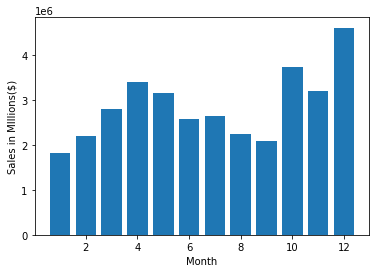

In [29]:
import matplotlib.pyplot as plt

month = range(1,13)
plt.bar(month,monthly_sales)
#plt.xticks(month)
plt.ylabel('Sales in MIllions($)')
plt.xlabel('Month')

plt.show()


### Answer:  From the bar chart above we can conclude base on the data at hand that in Decemeber we have the highest sales.Decmebers has been quite favourable to the company 

# QUESTION 2:  which city has the max order?

In [30]:
# checking the unique values in the purchase address column
df['Purchase Address'].unique()

array(['917 1st St, Dallas, TX 75001',
       '682 Chestnut St, Boston, MA 02215',
       '669 Spruce St, Los Angeles, CA 90001', ...,
       '981 4th St, New York City, NY 10001',
       '840 Highland St, Los Angeles, CA 90001',
       '220 12th St, San Francisco, CA 94016'], dtype=object)

In [31]:
# creating a function to split the city from the purchase address column 
def city(x):
    return x.split(',')[1]

df['city']=df['Purchase Address'].apply(city) # implimenting the function

In [32]:
df

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,city
0,176558,USB-C Charging Cable,2,11.950000,4/19/2019 8:46,"917 1st St, Dallas, TX 75001",4,23.900000,Dallas
2,176559,Bose SoundSport Headphones,1,99.989998,4/7/2019 22:30,"682 Chestnut St, Boston, MA 02215",4,99.989998,Boston
3,176560,Google Phone,1,600.000000,4/12/2019 14:38,"669 Spruce St, Los Angeles, CA 90001",4,600.000000,Los Angeles
4,176560,Wired Headphones,1,11.990000,4/12/2019 14:38,"669 Spruce St, Los Angeles, CA 90001",4,11.990000,Los Angeles
5,176561,Wired Headphones,1,11.990000,4/30/2019 9:27,"333 8th St, Los Angeles, CA 90001",4,11.990000,Los Angeles
...,...,...,...,...,...,...,...,...,...
186845,259353,AAA Batteries (4-pack),3,2.990000,9/17/2019 20:56,"840 Highland St, Los Angeles, CA 90001",9,8.970000,Los Angeles
186846,259354,iPhone,1,700.000000,9/1/2019 16:00,"216 Dogwood St, San Francisco, CA 94016",9,700.000000,San Francisco
186847,259355,iPhone,1,700.000000,9/23/2019 7:39,"220 12th St, San Francisco, CA 94016",9,700.000000,San Francisco
186848,259356,34in Ultrawide Monitor,1,379.989990,9/19/2019 17:30,"511 Forest St, San Francisco, CA 94016",9,379.989990,San Francisco


In [33]:
#grouping the quantity ordered by the cities they customers ordered from 
df.groupby('city')['Quantity Ordered'].sum()

city
 Atlanta          16584
 Austin           11137
 Boston           22494
 Dallas           16707
 Los Angeles      33247
 New York City    27903
 Portland         14037
 San Francisco    50169
 Seattle          16534
Name: Quantity Ordered, dtype: int32

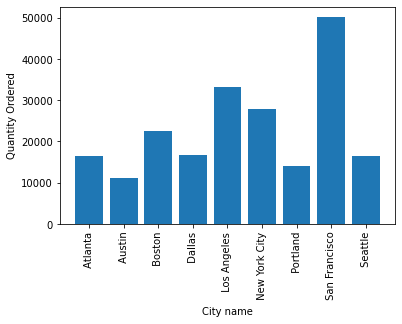

In [34]:
# Plotting city name by the total quantity ordered from that city
plt.bar(df.groupby('city')['Quantity Ordered'].sum().index,df.groupby('city')['Quantity Ordered'].sum())
plt.xticks(rotation='vertical')
plt.ylabel('Quantity Ordered')
plt.xlabel('City name')
plt.show()

### Answer:  With the graphical representation above, we can conclude thst san francisco has the highest overall order.

# QUESTION3: what time should we display advertisment to maximise for product?

In [35]:
# adding 'Hour' column to the data set, from extracting the hour from the 'order date'
df['Hour'] = pd.to_datetime(df['Order Date']).dt.hour

In [36]:
# grouping the Hours at which customers make an order by the Hour of the day and count
df.groupby('Hour')['Hour'].count()

Hour
0      3902
1      2347
2      1242
3       830
4       852
5      1320
6      2481
7      4002
8      6252
9      8740
10    10929
11    12392
12    12573
13    12115
14    10965
15    10159
16    10359
17    10884
18    12263
19    12886
20    12218
21    10905
22     8808
23     6262
Name: Hour, dtype: int64

In [37]:
# Creating a list to store the Hour and the cumulative number of the hours
keys =[]
hour =[]

for key,Hour in df.groupby('Hour'):
    keys.append(key)
    hour.append(len(Hour))

In [38]:
print(keys,end='')

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]

In [39]:
print(hour,end='')

[3902, 2347, 1242, 830, 852, 1320, 2481, 4002, 6252, 8740, 10929, 12392, 12573, 12115, 10965, 10159, 10359, 10884, 12263, 12886, 12218, 10905, 8808, 6262]

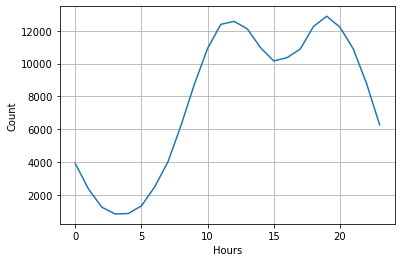

In [53]:
plt.plot(keys,hour)
plt.xlabel('Hours')
plt.ylabel("Count")
plt.grid()

 ## Answer:
Best Times to Advertise:
To maximize orders, you should focus advertising efforts during the hours leading up to and during the peak order times. This ensures the product is top-of-mind when customers are most likely to order.

Recommended Advertising Windows:
Late Morning to Early Afternoon:

10:00 AM - 1:00 PM: Covers the pre-lunch peak (11:00 AM - 12:00 PM).

Why? Orders are consistently high during this period, and advertising here can capture the lunchtime demand.

Evening:

5:00 PM - 8:00 PM: Covers the evening peak (18:00 PM - 19:00 PM).

Why? The highest order volume occurs at 7 PM, and this window captures the after-work and dinner demand.

# QUESTION 4: what product sold the most? and why?

In [42]:
df['Price Each'].unique()


array([  11.95,   99.99,  600.  ,   11.99, 1700.  ,   14.95,  389.99,
          3.84,  150.  ,    2.99,  700.  ,  300.  ,  149.99,  109.99,
        999.99,  400.  ,  379.99], dtype=float32)

In [43]:
# grouping the mean price  by product
df.groupby('Product')['Price Each'].mean()

Product
20in Monitor                   109.989998
27in 4K Gaming Monitor         389.989990
27in FHD Monitor               149.990005
34in Ultrawide Monitor         379.989990
AA Batteries (4-pack)            3.840000
AAA Batteries (4-pack)           2.990000
Apple Airpods Headphones       150.000000
Bose SoundSport Headphones      99.989998
Flatscreen TV                  300.000000
Google Phone                   600.000000
LG Dryer                       600.000000
LG Washing Machine             600.000000
Lightning Charging Cable        14.950000
Macbook Pro Laptop            1700.000000
ThinkPad Laptop                999.989990
USB-C Charging Cable            11.950000
Vareebadd Phone                400.000000
Wired Headphones                11.990000
iPhone                         700.000000
Name: Price Each, dtype: float32

In [55]:
products= df.groupby('Product')['Quantity Ordered'].sum().index # making 'product' the product name 
quantity = df.groupby('Product')['Quantity Ordered'].sum() # making the values to be quantity
prices = df.groupby('Product')['Price Each'].mean() # 'Prices' to be the means of the product price each

<Figure size 864x576 with 0 Axes>

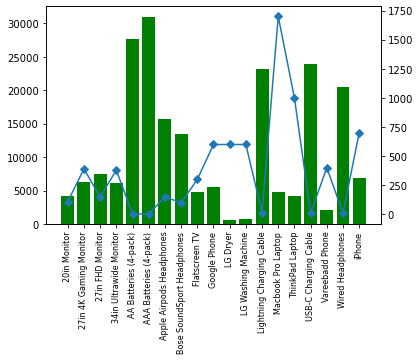

In [45]:
# Plot the product against Price and plot the product by the means price
plt.figure(figsize=(12,8))
fig,ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.bar(products, quantity, color='g') # plot of product by quantity 
ax2.plot(products,prices, 'D-')  # plot product by mean price 
ax1.set_xticklabels(products, rotation='vertical', size=8)
plt.show()

### Answer:The top selling is "AAA Battery". The top selling product seem to have a correlation with the price of the product. the cheaper the product the higher the quantity ordered and vice versa.

# QUESTION 5: what product are most often sold together?

In [46]:
# note: orders that have same orderID, are sold mostly together

In [47]:
# outputing the duplicate
df=df[df['Order ID'].duplicated(keep=False)]
df.head(20)

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,city,Hour
3,176560,Google Phone,1,600.000000,4/12/2019 14:38,"669 Spruce St, Los Angeles, CA 90001",4,600.000000,Los Angeles,14
4,176560,Wired Headphones,1,11.990000,4/12/2019 14:38,"669 Spruce St, Los Angeles, CA 90001",4,11.990000,Los Angeles,14
18,176574,Google Phone,1,600.000000,4/3/2019 19:42,"20 Hill St, Los Angeles, CA 90001",4,600.000000,Los Angeles,19
19,176574,USB-C Charging Cable,1,11.950000,4/3/2019 19:42,"20 Hill St, Los Angeles, CA 90001",4,11.950000,Los Angeles,19
32,176586,AAA Batteries (4-pack),2,2.990000,4/10/2019 17:00,"365 Center St, San Francisco, CA 94016",4,5.980000,San Francisco,17
33,176586,Google Phone,1,600.000000,4/10/2019 17:00,"365 Center St, San Francisco, CA 94016",4,600.000000,San Francisco,17
119,176672,Lightning Charging Cable,1,14.950000,4/12/2019 11:07,"778 Maple St, New York City, NY 10001",4,14.950000,New York City,11
120,176672,USB-C Charging Cable,1,11.950000,4/12/2019 11:07,"778 Maple St, New York City, NY 10001",4,11.950000,New York City,11
129,176681,Apple Airpods Headphones,1,150.000000,4/20/2019 10:39,"331 Cherry St, Seattle, WA 98101",4,150.000000,Seattle,10
130,176681,ThinkPad Laptop,1,999.989990,4/20/2019 10:39,"331 Cherry St, Seattle, WA 98101",4,999.989990,Seattle,10


In [48]:
# Creating a grouped column for the product that has the same order ID
df['Grouped'] = df.groupby('Order ID')['Product'].transform(lambda x: ','.join(x))

In [49]:
df

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,city,Hour,Grouped
3,176560,Google Phone,1,600.00,4/12/2019 14:38,"669 Spruce St, Los Angeles, CA 90001",4,600.00,Los Angeles,14,"Google Phone,Wired Headphones"
4,176560,Wired Headphones,1,11.99,4/12/2019 14:38,"669 Spruce St, Los Angeles, CA 90001",4,11.99,Los Angeles,14,"Google Phone,Wired Headphones"
18,176574,Google Phone,1,600.00,4/3/2019 19:42,"20 Hill St, Los Angeles, CA 90001",4,600.00,Los Angeles,19,"Google Phone,USB-C Charging Cable"
19,176574,USB-C Charging Cable,1,11.95,4/3/2019 19:42,"20 Hill St, Los Angeles, CA 90001",4,11.95,Los Angeles,19,"Google Phone,USB-C Charging Cable"
32,176586,AAA Batteries (4-pack),2,2.99,4/10/2019 17:00,"365 Center St, San Francisco, CA 94016",4,5.98,San Francisco,17,"AAA Batteries (4-pack),Google Phone"
...,...,...,...,...,...,...,...,...,...,...,...
186792,259303,AA Batteries (4-pack),1,3.84,9/20/2019 20:18,"106 7th St, Atlanta, GA 30301",9,3.84,Atlanta,20,"34in Ultrawide Monitor,AA Batteries (4-pack)"
186803,259314,Wired Headphones,1,11.99,9/16/2019 0:25,"241 Highland St, Atlanta, GA 30301",9,11.99,Atlanta,0,"Wired Headphones,AAA Batteries (4-pack)"
186804,259314,AAA Batteries (4-pack),2,2.99,9/16/2019 0:25,"241 Highland St, Atlanta, GA 30301",9,5.98,Atlanta,0,"Wired Headphones,AAA Batteries (4-pack)"
186841,259350,Google Phone,1,600.00,9/30/2019 13:49,"519 Maple St, San Francisco, CA 94016",9,600.00,San Francisco,13,"Google Phone,USB-C Charging Cable"


In [50]:
# Duplicating the dataset and dropping the duplicate Order Id 
df2 = df.drop_duplicates(subset=['Order ID'])

In [51]:
df2

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,city,Hour,Grouped
3,176560,Google Phone,1,600.00000,4/12/2019 14:38,"669 Spruce St, Los Angeles, CA 90001",4,600.00000,Los Angeles,14,"Google Phone,Wired Headphones"
18,176574,Google Phone,1,600.00000,4/3/2019 19:42,"20 Hill St, Los Angeles, CA 90001",4,600.00000,Los Angeles,19,"Google Phone,USB-C Charging Cable"
32,176586,AAA Batteries (4-pack),2,2.99000,4/10/2019 17:00,"365 Center St, San Francisco, CA 94016",4,5.98000,San Francisco,17,"AAA Batteries (4-pack),Google Phone"
119,176672,Lightning Charging Cable,1,14.95000,4/12/2019 11:07,"778 Maple St, New York City, NY 10001",4,14.95000,New York City,11,"Lightning Charging Cable,USB-C Charging Cable"
129,176681,Apple Airpods Headphones,1,150.00000,4/20/2019 10:39,"331 Cherry St, Seattle, WA 98101",4,150.00000,Seattle,10,"Apple Airpods Headphones,ThinkPad Laptop"
...,...,...,...,...,...,...,...,...,...,...,...
186761,259277,iPhone,1,700.00000,9/28/2019 13:07,"795 Willow St, New York City, NY 10001",9,700.00000,New York City,13,"iPhone,Wired Headphones"
186783,259297,iPhone,1,700.00000,9/15/2019 18:54,"138 Main St, Boston, MA 02215",9,700.00000,Boston,18,"iPhone,Lightning Charging Cable"
186791,259303,34in Ultrawide Monitor,1,379.98999,9/20/2019 20:18,"106 7th St, Atlanta, GA 30301",9,379.98999,Atlanta,20,"34in Ultrawide Monitor,AA Batteries (4-pack)"
186803,259314,Wired Headphones,1,11.99000,9/16/2019 0:25,"241 Highland St, Atlanta, GA 30301",9,11.99000,Atlanta,0,"Wired Headphones,AAA Batteries (4-pack)"


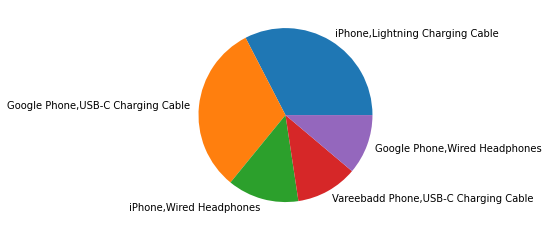

In [52]:
# first five most common pair orders
df2['Grouped'].value_counts()[0:5].plot.pie()
plt.ylabel('')   # Removes the default y-label (often the column name)
plt.show()

## Answer: The first first most paired orders are Google phone with USB-C charging cable, Iphone with Lightning charging cable, Google phone with Wired Headphones, Iphone with Wired Headphones and Vareebadd phone with USB-C Charging Cable